## TACTICAL PLAYER ROLE MAPPER

### FIFA World Cup 2026 Player Analysis

#### Overview

This notebook clusters World Cup 2026 players into tactical archetypes 
(e.g. "The Engine", "The Playmaker") using unsupervised learning, 
then uses those archetypes to build balanced starting XIs for major nations.

**Pipeline:** data cleaning & deduplication → feature selection → PCA → 
K-Means clustering → role naming → team optimization → pitch visualization

**Why PCA before clustering?** The 20 selected performance features are 
correlated (e.g. successful_passes and pass_accuracy). PCA reduces 
dimensionality while retaining 85% of variance, which makes the 
downstream K-Means clusters more stable and less dominated by 
correlated features.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset/fifa_world_cup_2026_player_performance.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# For pitch visualization
import matplotlib.patches as patches
from matplotlib.patches import Circle, Rectangle, Arc

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

In [3]:
df = pd.read_csv('/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset/fifa_world_cup_2026_player_performance.csv')

In [4]:
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
display(df.head())
print("\nLast 5 rows:")
display(df.tail())

Shape: (54600, 75)

Columns: ['player_id', 'player_name', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score', 'player_rati

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7



Last 5 rows:


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
54595,P00996,Amir Younis,28,Iraqi,Iraq,8,Defender,177,73,Right,...,0.0,41.9,27.7,31.3,40.5,1,0,97,0,0.0
54596,P01006,Safaa Al-Khafaji,20,Iraqi,Iraq,18,Midfielder,176,72,Right,...,0.0,64.2,53.1,64.8,64.3,2,0,206,0,0.0
54597,P01008,Ahmed Hussein,26,Iraqi,Iraq,20,Midfielder,173,77,Left,...,0.0,75.4,55.0,65.0,64.5,1,1,359,0,0.0
54598,P00991,Ibrahim Mhawi,30,Iraqi,Iraq,3,Goalkeeper,190,81,Right,...,0.0,96.3,39.6,99.0,99.0,0,0,342,0,0.0
54599,P00989,Mohannad Hussein,27,Iraqi,Iraq,1,Goalkeeper,187,73,Right,...,0.0,99.0,34.1,99.0,99.0,0,0,286,0,0.0


In [5]:
df.describe()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


In [6]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values/len(df))*100
missing_df = pd.DataFrame({
    "Missing Count" : missing_values,
    "Missing %" : missing_percentage
})

display(missing_df[missing_df['Missing Count']>0].sort_values('Missing Count', ascending=False))

,Missing Count,Missing %


In [7]:
print("POSITIONS IN DATASET")
print(df['position'].value_counts())

POSITIONS IN DATASET
position
Defender      18900
Midfielder    16800
Forward       12600
Goalkeeper     6300
Name: count, dtype: int64


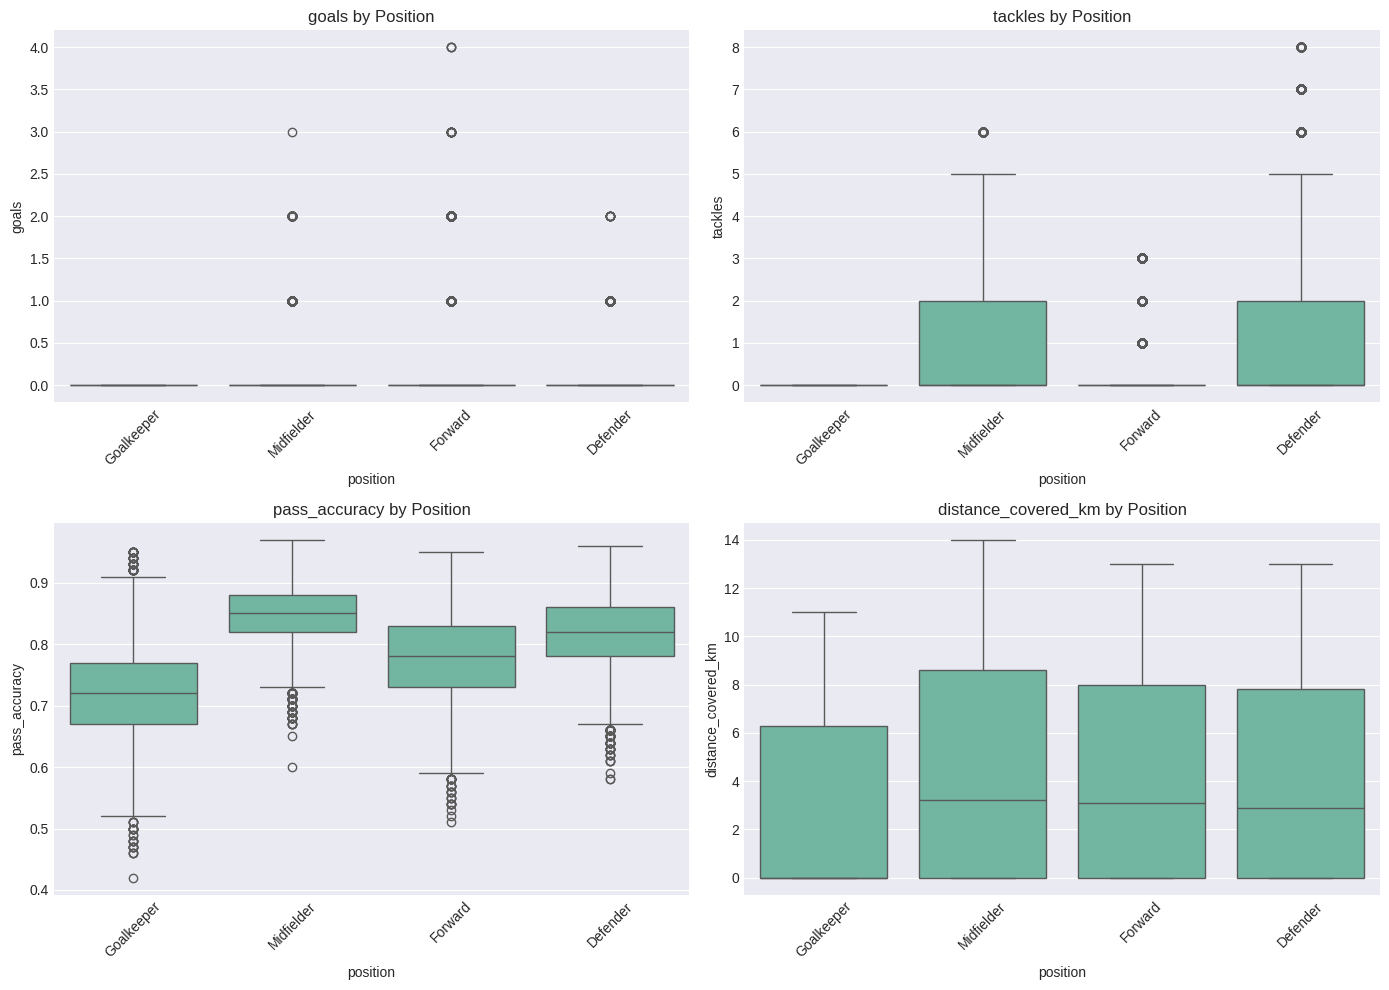

In [8]:
# Distribution of key stats by position
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
stats_to_plot = ['goals', 'tackles', 'pass_accuracy', 'distance_covered_km']

for ax, stat in zip(axes.flatten(), stats_to_plot):
    sns.boxplot(data=df, x='position', y=stat, ax=ax)
    ax.set_title(f'{stat} by Position')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

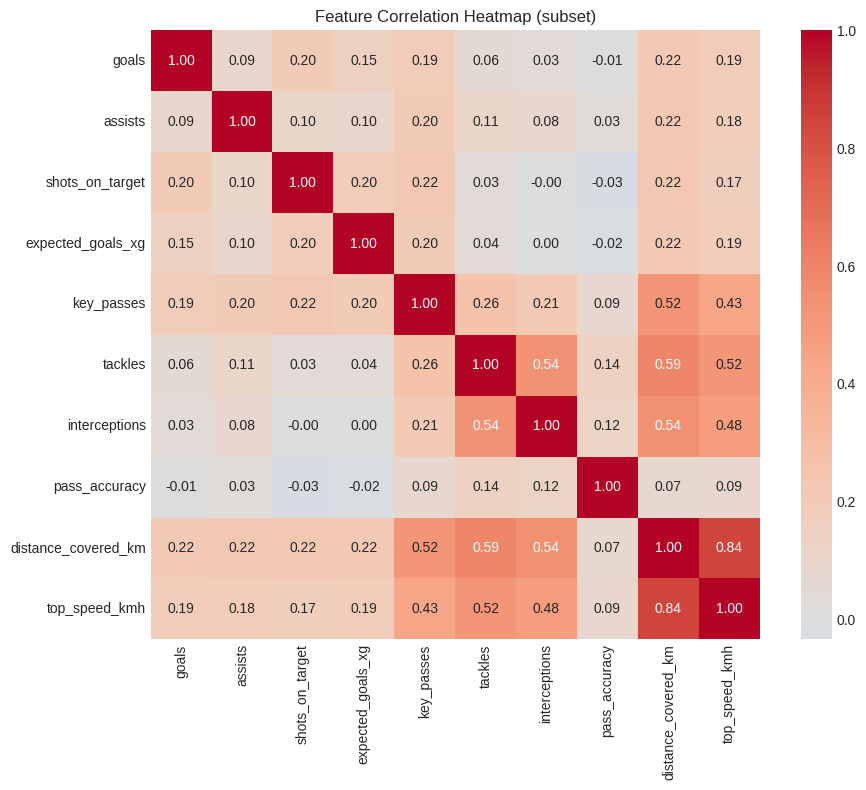

In [9]:
# Correlation heatmap of features used for clustering
selected_features_preview = [
    'goals', 'assists', 'shots_on_target', 'expected_goals_xg',
    'key_passes', 'tackles', 'interceptions', 'pass_accuracy',
    'distance_covered_km', 'top_speed_kmh'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[selected_features_preview].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Heatmap (subset)')
plt.tight_layout()
plt.show()

In [10]:
# Goalkeepers have different stats (saves, clean sheets) that don't apply to outfield players

gk_columns = ['saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves']
for col in gk_columns:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [11]:
# ============================================
#PLAYER DEDUPLICATION 
# ============================================

def deduplicate_players(df):
    """
    Remove duplicate player entries by aggregating match-level data
    to player-level data
    
    Issue: Same players appear multiple times
    Solution: Group by player_id and aggregate statistics
    """
    
    print(f"Original rows: {len(df)}")
    print(f"Unique player_ids: {df['player_id'].nunique()}")
    
    # Define aggregation rules for different column types
    agg_dict = {
        'player_name': 'first',
        'age': 'first',
        'nationality': 'first',
        'team': 'first',
        'position': 'first',  # Will be refined later
        'jersey_number': 'first',
        'height_cm': 'first',
        'weight_kg': 'first',
        'preferred_foot': 'first',
        'club_name': 'first',
        'market_value_eur': 'first',
        'match_id': 'count',  # Number of matches played
    }
    
    # For performance stats, take the mean (average per match)
    performance_cols = [
        'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target',
        'expected_goals_xg', 'expected_assists_xa', 'key_passes',
        'successful_passes', 'total_passes', 'pass_accuracy',
        'dribbles_attempted', 'successful_dribbles', 'crosses',
        'successful_crosses', 'tackles', 'interceptions', 'clearances',
        'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
        'defensive_actions', 'fouls_committed', 'fouls_suffered',
        'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
        'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
        'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh',
        'accelerations', 'decelerations', 'stamina_score',
        'player_rating', 'performance_score', 'offensive_contribution',
        'defensive_contribution', 'possession_impact', 'pressure_resistance',
        'creativity_score', 'consistency_score', 'clutch_performance_score'
    ]
    
    for col in performance_cols:
        if col in df.columns:
            agg_dict[col] = 'mean'
    
    # For tournament totals, take the max
    tournament_cols = [
        'total_goals_tournament', 'total_assists_tournament',
        'total_minutes_tournament', 'player_of_match_awards',
        'tournament_rating'
    ]
    
    for col in tournament_cols:
        if col in df.columns:
            agg_dict[col] = 'max'
    
    # Group and aggregate
    df_dedup = df.groupby('player_id').agg(agg_dict).reset_index()
    
    # Fix column names that might have been renamed
    if 'match_id_count' in df_dedup.columns:
        df_dedup = df_dedup.rename(columns={'match_id_count': 'matches_played'})
    
    print(f"After deduplication: {len(df_dedup)} unique players")
    
    # Fix position mapping (Issue #3)
    df_dedup = fix_position_mapping(df_dedup)
    
    return df_dedup

def fix_position_mapping(df):
    """
    Fix position mapping issues where players appear in multiple positions
    
    Issue: A player shouldn't appear as both Defender and Midfielder
    Solution: Determine the primary position based on statistics
    """
    
    # If we have position information, use it
    if 'position' in df.columns:
        # Map positions to categories
        position_category_map = {
            'GK': 'Goalkeeper',
            'Defender': 'Defender',
            'Midfielder': 'Midfielder',
            'Forward': 'Forward'
        }
        
        # For players with mixed positions, we need to determine primary
        # Since we deduplicated, each player should have one position
        # But if there are still issues, we'll use the most common
        df['position_category'] = df['position'].map(position_category_map)
        
        # If any players have null position_category, infer from stats
        mask = df['position_category'].isna()
        if mask.any():
            print(f"Inferring positions for {mask.sum()} players...")
            
            for idx in df[mask].index:
                player = df.loc[idx]
                
                # Infer position based on stats
                if player.get('saves', 0) > 0 or player.get('save_percentage', 0) > 0:
                    df.loc[idx, 'position_category'] = 'Goalkeeper'
                elif player.get('clearances', 0) > 5 or player.get('tackles', 0) > 3:
                    df.loc[idx, 'position_category'] = 'Defender'
                elif player.get('goals', 0) > 1 or player.get('assists', 0) > 1:
                    df.loc[idx, 'position_category'] = 'Forward'
                else:
                    df.loc[idx, 'position_category'] = 'Midfielder'
    
    print(f"Position distribution after fixing:")
    print(df['position_category'].value_counts())
    
    return df

# Apply deduplication
df_clean = deduplicate_players(df)

Original rows: 54600
Unique player_ids: 1248
After deduplication: 1248 unique players
Inferring positions for 144 players...
Position distribution after fixing:
position_category
Defender      432
Midfielder    384
Forward       288
Goalkeeper    144
Name: count, dtype: int64


In [12]:
# ============================================
# FEATURE SELECTION & PCA
# ============================================

# Select performance features for clustering
selected_features = [
    'goals', 'assists', 'shots_on_target', 'expected_goals_xg',
    'expected_assists_xa', 'key_passes', 'successful_dribbles',
    'successful_crosses', 'tackles', 'interceptions', 'clearances',
    'blocks', 'aerial_duels_won', 'recoveries', 'distance_covered_km',
    'sprint_distance_km', 'top_speed_kmh', 'accelerations',
    'decelerations', 'pass_accuracy', 'successful_passes'
]

# Filter out players with all zeros (or very low stats)
df_filtered = df_clean[df_clean[selected_features].sum(axis=1) > 0.1].copy()
print(f"Players with meaningful stats: {len(df_filtered)}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filtered[selected_features])

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Determine optimal number of components
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
n_components = np.where(cumulative_variance >= 0.85)[0][0] + 1

print(f"Optimal PCA components: {n_components} (explains 85% variance)")

X_pca_optimal = X_pca[:, :n_components]

Players with meaningful stats: 1248
Optimal PCA components: 5 (explains 85% variance)


K=2: Silhouette Score=0.334
K=3: Silhouette Score=0.379
K=4: Silhouette Score=0.425
K=5: Silhouette Score=0.387
K=6: Silhouette Score=0.390
K=7: Silhouette Score=0.353
K=8: Silhouette Score=0.344
K=9: Silhouette Score=0.325
K=10: Silhouette Score=0.301


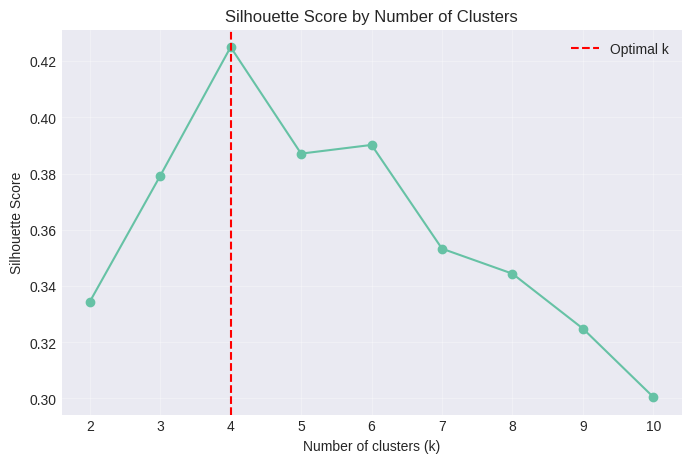


Optimal clusters: 4


In [13]:
# ============================================
# CLUSTERING - PLAYER ROLES
# ============================================

# Find optimal number of clusters
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_optimal)
    score = silhouette_score(X_pca_optimal, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score={score:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.axvline(x=range(2, 11)[np.argmax(silhouette_scores)], color='red',
            linestyle='--', label='Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

optimal_k = range(2, 11)[np.argmax(silhouette_scores)]
print(f"\nOptimal clusters: {optimal_k}")

# Apply K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_filtered['cluster'] = kmeans.fit_predict(X_pca_optimal)

In [14]:
# ============================================
# ROLE NAMING
# ============================================

# Calculate cluster means
cluster_means = df_filtered.groupby('cluster')[selected_features].mean()
overall_means = df_filtered[selected_features].mean()

# Name clusters based on distinctive features
role_names = {}

for cluster_id in range(optimal_k):
    # Get relative strengths
    relative = (cluster_means.loc[cluster_id] / overall_means) - 1
    top_strengths = relative.nlargest(3)
    
    # Name based on strengths
    if 'distance_covered_km' in top_strengths.index and top_strengths['distance_covered_km'] > 0.3:
        role = "The Engine"
    elif 'tackles' in top_strengths.index and top_strengths['tackles'] > 0.3:
        role = "The Destroyer"
    elif 'pass_accuracy' in top_strengths.index and top_strengths['pass_accuracy'] > 0.2:
        role = "The Playmaker"
    elif 'goals' in top_strengths.index and top_strengths['goals'] > 0.3:
        role = "The Poacher"
    elif 'successful_crosses' in top_strengths.index and top_strengths['successful_crosses'] > 0.5:
        role = "The Crosser"
    elif 'clearances' in top_strengths.index and top_strengths['clearances'] > 0.5:
        role = "The Defender"
    elif 'shots_on_target' in top_strengths.index and top_strengths['shots_on_target'] > 1.0:
        role = "The Super Striker"
    else:
        role = "The All-Rounder"
    
    role_names[cluster_id] = role
    print(f"Cluster {cluster_id}: {role} ({len(df_filtered[df_filtered['cluster'] == cluster_id])} players)")

df_filtered['role'] = df_filtered['cluster'].map(role_names)

Cluster 0: The Defender (421 players)
Cluster 1: The All-Rounder (198 players)
Cluster 2: The Poacher (262 players)
Cluster 3: The All-Rounder (367 players)


In [15]:
# ============================================
# ADVANCED TEAM BUILDER
# ============================================


class OptimalTeamBuilder:
    """
    Advanced team builder that solves the "Too Many Cooks" problem
    by balancing individual quality with team composition
    """
    
    def __init__(self, df, role_names):
        self.df = df
        self.role_names = role_names
        self.n_roles = len(role_names)
        
        # Ideal archetype distribution for balanced teams
        self.ideal_roles = {
            'The Engine': 2,
            'The Destroyer': 2,
            'The Playmaker': 2,
            'The Poacher': 2,
            'The Crosser': 1,
            'The Defender': 1,
            'The Super Striker': 1,
            'The All-Rounder': 2
        }
        
        # Position weights (importance)
        self.position_weights = {
            'Goalkeeper': 1.5,
            'Defender': 1.0,
            'Midfielder': 1.2,
            'Forward': 1.3
        }
    
    def calculate_team_score(self, selected_players, formation='4-3-3'):
        """
        Calculate composite score balancing:
        - Individual quality
        - Position balance
        - Role diversity
        - Team chemistry
        """
        if len(selected_players) < 11:
            return -1000
        
        # 1. Individual quality (60%)
        quality_score = np.mean([p['performance_score'] for p in selected_players])
        
        # 2. Position balance (20%)
        pos_counts = {}
        for p in selected_players:
            pos = p.get('position_category', 'Midfielder')
            pos_counts[pos] = pos_counts.get(pos, 0) + 1
        
        ideal_positions = {
            'Goalkeeper': 1,
            'Defender': 4,
            'Midfielder': 3,
            'Forward': 3
        }
        
        position_score = 0
        for pos, ideal in ideal_positions.items():
            actual = pos_counts.get(pos, 0)
            # Penalize deviation more heavily
            diff = abs(actual - ideal)
            if diff <= 1:
                position_score += 1.0
            elif diff <= 2:
                position_score += 0.5
            else:
                position_score += 0.0
        
        position_score = position_score / len(ideal_positions)
        
        # 3. Role diversity (20%) - The "Too Many Cooks" fix
        role_counts = {}
        for p in selected_players:
            role = self.role_names.get(p['cluster'], 'Unknown')
            role_counts[role] = role_counts.get(role, 0) + 1
        
        # Calculate diversity score
        unique_roles = len(role_counts)
        diversity_score = unique_roles / self.n_roles
        
        # Also check if we have good role distribution
        distribution_score = 0
        for role, ideal in self.ideal_roles.items():
            actual = role_counts.get(role, 0)
            if actual >= ideal * 0.5:  # At least 50% of ideal
                distribution_score += 1
        distribution_score = distribution_score / len(self.ideal_roles)
        
        role_score = 0.5 * diversity_score + 0.5 * distribution_score
        
        # 4. Chemistry bonus (players from same club)
        club_counts = {}
        for p in selected_players:
            club = p.get('club_name', 'Unknown')
            club_counts[club] = club_counts.get(club, 0) + 1
        
        chemistry_bonus = 0
        for club, count in club_counts.items():
            if count >= 3:
                chemistry_bonus += 0.02 * (count - 2)
        
        # Combine scores
        total_score = (
            0.60 * (quality_score / 100) +
            0.20 * position_score +
            0.20 * role_score +
            0.05 * chemistry_bonus
        )
        
        return total_score
    
    def build_optimal_team(self, team_name, formation='4-3-3', 
                          strategy='balanced', n_iterations=500):
        """
        Build optimal team using genetic algorithm approach
        
        Parameters:
        - team_name: Name of the team
        - formation: '4-3-3', '4-4-2', or '3-5-2'
        - strategy: 'balanced', 'quality_first', or 'diversity_first'
        - n_iterations: Number of optimization iterations
        """
        
        # Filter players for this team
        team_players = self.df[self.df['team'] == team_name].copy()
        
        if len(team_players) == 0:
            print(f"No players found for team: {team_name}")
            return None
        
        print(f"\nBuilding optimal {formation} formation for {team_name}")
        print(f"Available players: {len(team_players)}")
        print(f"Strategy: {strategy}")
        
        # Define position requirements
        if formation == '4-3-3':
            position_requirements = {
                'Goalkeeper': 1,
                'Defender': 4,
                'Midfielder': 3,
                'Forward': 3
            }
        elif formation == '4-4-2':
            position_requirements = {
                'Goalkeeper': 1,
                'Defender': 4,
                'Midfielder': 4,
                'Forward': 2
            }
        elif formation == '3-5-2':
            position_requirements = {
                'Goalkeeper': 1,
                'Defender': 3,
                'Midfielder': 5,
                'Forward': 2
            }
        else:
            position_requirements = {
                'Goalkeeper': 1,
                'Defender': 4,
                'Midfielder': 3,
                'Forward': 3
            }
        
        # Get players by position
        position_players = {}
        for pos in position_requirements.keys():
            pos_players = team_players[team_players['position_category'] == pos]
            if len(pos_players) >= position_requirements[pos]:
                position_players[pos] = pos_players
            else:
                # If not enough players, use all available and note the shortage
                position_players[pos] = pos_players
                print(f"  Warning: Only {len(pos_players)} {pos}s available (need {position_requirements[pos]})")
        
        # If we don't have enough players overall, return None
        total_available = sum(len(p) for p in position_players.values())
        if total_available < 11:
            print(f"  Not enough players overall: {total_available}")
            return None
        
        # Generate candidate teams using genetic algorithm
        best_team = None
        best_score = -float('inf')
        best_players = None
        
        for iteration in range(n_iterations):
            selected = []
            
            # Select players for each position
            for pos, required_count in position_requirements.items():
                if pos in position_players:
                    pos_df = position_players[pos]
                    available = len(pos_df)
                    
                    if available >= required_count:
                        # Select players based on strategy
                        if strategy == 'quality_first':
                            # Pick the best players
                            selected_players = pos_df.nlargest(required_count, 'performance_score')
                        elif strategy == 'diversity_first':
                            # Pick players with diverse roles
                            selected_players = self._select_diverse_players(pos_df, required_count)
                        else:
                            # Balanced: weighted random selection
                            weights = pos_df['performance_score'] / pos_df['performance_score'].sum()
                            selected_indices = np.random.choice(
                                pos_df.index,
                                size=min(required_count, len(pos_df)),
                                replace=False,
                                p=weights
                            )
                            selected_players = pos_df.loc[selected_indices]
                        
                        selected.extend(selected_players.to_dict('records'))
            
            # If we don't have enough players, fill with best available
            if len(selected) < 11:
                used_ids = [p['player_id'] for p in selected]
                remaining = team_players[~team_players['player_id'].isin(used_ids)]
                needed = 11 - len(selected)
                additional = remaining.nlargest(needed, 'performance_score')
                selected.extend(additional.to_dict('records'))
            
            # Evaluate this team
            score = self.calculate_team_score(selected, formation)
            
            # Apply strategy bonuses
            if strategy == 'quality_first':
                quality = np.mean([p['performance_score'] for p in selected])
                score = score * (1 + 0.1 * quality / 100)
            elif strategy == 'diversity_first':
                roles = set([self.role_names.get(p['cluster'], 'Unknown') for p in selected])
                diversity = len(roles) / self.n_roles
                score = score * (1 + 0.2 * diversity)
            
            if score > best_score:
                best_score = score
                best_players = selected
        
        # Build final team data
        if best_players:
            # Ensure we have exactly 11 players
            best_players = best_players[:11]
            
            # Calculate team statistics
            avg_rating = np.mean([p['player_rating'] for p in best_players])
            avg_performance = np.mean([p['performance_score'] for p in best_players])
            
            # Get role distribution
            role_counts = {}
            for p in best_players:
                role = self.role_names.get(p['cluster'], 'Unknown')
                role_counts[role] = role_counts.get(role, 0) + 1
            
            # Get position distribution
            pos_counts = {}
            for p in best_players:
                pos = p.get('position_category', 'Midfielder')
                pos_counts[pos] = pos_counts.get(pos, 0) + 1
            
            return {
                'team': team_name,
                'formation': formation,
                'strategy': strategy,
                'players': best_players,
                'score': best_score,
                'avg_rating': avg_rating,
                'avg_performance': avg_performance,
                'role_distribution': role_counts,
                'position_distribution': pos_counts,
                'n_players': len(best_players)
            }
        
        return None
    
    def _select_diverse_players(self, players_df, n_select):
        """Select players to maximize role diversity"""
        if len(players_df) <= n_select:
            return players_df
        
        selected = []
        used_roles = set()
        selected_ids = []
        
        # First, try to get one from each role
        for role_id in range(self.n_roles):
            if len(selected) >= n_select:
                break
            
            role_players = players_df[players_df['cluster'] == role_id]
            if len(role_players) > 0:
                # Get best player from this role
                best = role_players.loc[role_players['performance_score'].idxmax()]
                selected.append(best)
                selected_ids.append(best['player_id'])
                used_roles.add(role_id)
        
        # If we still need more, get the best remaining
        if len(selected) < n_select:
            remaining = players_df[~players_df['player_id'].isin(selected_ids)]
            additional = remaining.nlargest(n_select - len(selected), 'performance_score')
            selected.extend(additional.to_dict('records'))
        
        return pd.DataFrame(selected)

# Create team builder
builder = OptimalTeamBuilder(df_filtered, role_names)

In [16]:
# ============================================
# 1. PITCH DRAWING FUNCTION
# ============================================

def draw_soccer_pitch(ax=None, pitch_color='green'):
    """
    Draw a beautiful soccer pitch with proper dimensions
    
    Parameters:
    - ax: matplotlib axis (creates new if None)
    - pitch_color: 'green'
    
    Returns:
    - ax: matplotlib axis with pitch drawn
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
        fig.patch.set_facecolor('#2E8B57' if pitch_color == 'green' else '#f0f0f0')
    
    # Pitch dimensions
    pitch_length = 105
    pitch_width = 68
    
    # Set colors
    if pitch_color == 'green':
        pitch_bg = '#2E8B57'
        line_color = 'white'
    else:
        pitch_bg = '#f0f0f0'
        line_color = 'black'
    
    # Set background
    ax.set_facecolor(pitch_bg)
    ax.set_xlim(-5, pitch_length + 5)
    ax.set_ylim(-5, pitch_width + 5)

        # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Pitch outline
    pitch_rect = Rectangle((0, 0), pitch_length, pitch_width, 
                          fill=False, edgecolor=line_color, linewidth=3)
    ax.add_patch(pitch_rect)
    
    # Center line
    ax.plot([pitch_length/2, pitch_length/2], [0, pitch_width], 
            color=line_color, linewidth=2)
    
    # Center circle
    center_circle = Circle((pitch_length/2, pitch_width/2), 9.15, 
                          fill=False, edgecolor=line_color, linewidth=2)
    ax.add_patch(center_circle)
    
    # Center spot
    center_spot = Circle((pitch_length/2, pitch_width/2), 0.5, 
                        color=line_color, alpha=0.5)
    ax.add_patch(center_spot)
    
    # Goal areas (6-yard boxes)
    goal_area_width = 18.32
    goal_area_height = 11
    
    # Left goal area
    goal_area_left = Rectangle((0, (pitch_width - goal_area_height)/2), 
                               goal_area_width, goal_area_height,
                               fill=False, edgecolor=line_color, linewidth=2)
    ax.add_patch(goal_area_left)
    
    # Right goal area
    goal_area_right = Rectangle((pitch_length - goal_area_width, 
                                 (pitch_width - goal_area_height)/2), 
                                goal_area_width, goal_area_height,
                                fill=False, edgecolor=line_color, linewidth=2)
    ax.add_patch(goal_area_right)
    
    # Penalty areas (18-yard boxes)
    penalty_area_width = 40.32
    penalty_area_height = 33
    
    # Left penalty area
    penalty_area_left = Rectangle((0, (pitch_width - penalty_area_height)/2), 
                                  penalty_area_width, penalty_area_height,
                                  fill=False, edgecolor=line_color, linewidth=2)
    ax.add_patch(penalty_area_left)
    
    # Right penalty area
    penalty_area_right = Rectangle((pitch_length - penalty_area_width, 
                                    (pitch_width - penalty_area_height)/2), 
                                   penalty_area_width, penalty_area_height,
                                   fill=False, edgecolor=line_color, linewidth=2)
    ax.add_patch(penalty_area_right)
    
    # Penalty spots
    penalty_spot_left = Circle((11, pitch_width/2), 0.5, 
                              color=line_color, alpha=0.5)
    ax.add_patch(penalty_spot_left)
    
    penalty_spot_right = Circle((pitch_length - 11, pitch_width/2), 0.5, 
                               color=line_color, alpha=0.5)
    ax.add_patch(penalty_spot_right)
    
    # Goal lines
    for y in [0, pitch_width]:
        ax.plot([0, 0], [y-2, y+2], color=line_color, linewidth=3)
        ax.plot([pitch_length, pitch_length], [y-2, y+2], color=line_color, linewidth=3)
    
    # Corner arcs
    corner_radius = 1
    corners = [(0, 0), (pitch_length, 0), (0, pitch_width), (pitch_length, pitch_width)]
    for corner in corners:
        corner_arc = Arc(corner, corner_radius*2, corner_radius*2, 
                        angle=0, theta1=0, theta2=90, 
                        edgecolor=line_color, linewidth=2)
        ax.add_patch(corner_arc)
    
    ax.set_aspect('equal')
    ax.axis('off')
    
    return ax


# ============================================
# 2. FIXED TEAM PITCH VISUALIZATION
# ============================================

def create_team_pitch_viz(team_data, role_names, title=None, formation='4-3-3'):
    """
    Create a visualization of the team on a soccer pitch
    
    Parameters:
    - team_data: Dictionary with team information
    - role_names: Dictionary mapping cluster to role name
    - title: Optional custom title
    - formation: Formation string (4-3-3, 4-4-2, 3-5-2)

    """
    
    # Validate input
    if not team_data:
        print("No team data available")
        return None
    
    if 'players' not in team_data or not team_data['players']:
        print("No players found in team data")
        return None
    
    try:
        # Create figure and pitch
        fig, ax = plt.subplots(figsize=(14, 10))
        fig.patch.set_facecolor('#2E8B57')  # Grass green
        draw_soccer_pitch(ax, pitch_color='green')
        
        # Define player positions based on formation
        # Coordinates: (x, y) where x is length (0-105) and y is width (0-68)
        
        if formation == '4-3-3':
            position_coords = {
                'Goalkeeper': [(7, 34)],
                'Defender': [
                    (18, 12),   # LB
                    (18, 28),   # LCB
                    (18, 40),   # RCB
                    (18, 56)    # RB
                ],
                'Midfielder': [
                    (42, 12),   # LM
                    (42, 34),   # CM
                    (42, 56)    # RM
                ],
                'Forward': [
                    (72, 10),   # LW
                    (78, 34),   # ST
                    (72, 58)    # RW
                ]
            }
        elif formation == '4-4-2':
            position_coords = {
                'Goalkeeper': [(7, 34)],
                'Defender': [
                    (18, 12),   # LB
                    (18, 28),   # LCB
                    (18, 40),   # RCB
                    (18, 56)    # RB
                ],
                'Midfielder': [
                    (42, 6),    # LM
                    (42, 22),   # LCM
                    (42, 46),   # RCM
                    (42, 62)    # RM
                ],
                'Forward': [
                    (78, 20),   # LS
                    (78, 48)    # RS
                ]
            }
        elif formation == '3-5-2':
            position_coords = {
                'Goalkeeper': [(7, 34)],
                'Defender': [
                    (18, 12),   # LCB
                    (18, 34),   # CB
                    (18, 56)    # RCB
                ],
                'Midfielder': [
                    (42, 6),    # LM
                    (42, 18),   # LCM
                    (42, 34),   # CM
                    (42, 50),   # RCM
                    (42, 62)    # RM
                ],
                'Forward': [
                    (78, 20),   # LS
                    (78, 48)    # RS
                ]
            }
        else:  # Default to 4-3-3
            position_coords = {
                'Goalkeeper': [(7, 34)],
                'Defender': [
                    (18, 12), (18, 28), (18, 40), (18, 56)
                ],
                'Midfielder': [
                    (42, 12), (42, 34), (42, 56)
                ],
                'Forward': [
                    (72, 10), (78, 34), (72, 58)
                ]
            }
        
        # Colors for roles
        role_color_map = {
            'The Engine': '#FF6B6B',
            'The Destroyer': '#4ECDC4',
            'The Playmaker': '#45B7D1',
            'The Poacher': '#96CEB4',
            'The Crosser': '#FFEAA7',
            'The Defender': '#DDA0DD',
            'The Super Striker': '#FF8C00',
            'The All-Rounder': '#A8D8EA'
        }
        default_color = '#808080'
        
        # Get players
        players = team_data['players'][:11]
        
        # Group players by position category
        players_by_pos = {
            'Goalkeeper': [],
            'Defender': [],
            'Midfielder': [],
            'Forward': []
        }
        
        for player in players:
            pos_category = player.get('position_category', 'Midfielder')
            if pos_category in players_by_pos:
                players_by_pos[pos_category].append(player)
            else:
                players_by_pos['Midfielder'].append(player)
        
        # Place players on the pitch
        for pos_category, pos_players in players_by_pos.items():
            if pos_category not in position_coords:
                continue
                
            coords_list = position_coords[pos_category]
            
            # Sort players by performance (best first)
            pos_players.sort(key=lambda x: x.get('performance_score', 0), reverse=True)
            
            # Place each player
            for i, player in enumerate(pos_players):
                if i >= len(coords_list):
                    break
                    
                x, y = coords_list[i]
                
                # Add small offset to avoid perfect alignment
                x += np.random.normal(0, 0.5)
                y += np.random.normal(0, 0.5)
                
                # Get role and color
                cluster = player.get('cluster', 0)
                role = role_names.get(cluster, 'Unknown')
                color = role_color_map.get(role, default_color)
                
                # Draw player circle with glow
                glow = Circle((x, y), 3.5, color=color, alpha=0.15, zorder=8)
                ax.add_patch(glow)
                
                # Main circle
                circle = Circle((x, y), 2.8, color=color, alpha=0.9, zorder=10,
                               ec='white', linewidth=2)
                ax.add_patch(circle)
                
                # Player name with background
                name = str(player.get('player_name', 'Unknown'))[:14]
                ax.text(x, y-4.5, name, fontsize=9, ha='center', va='top',
                       color='white', weight='bold', zorder=11,
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))
                
                # Role abbreviation
                role_short = role.replace('The ', '')[:8]
                ax.text(x, y-7, role_short, fontsize=7, ha='center', va='top',
                       color='white', alpha=1, zorder=11,
                       bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.5))
                
                # Position abbreviation
                pos_short = pos_category[:3] if pos_category else 'MID'
                ax.text(x, y+4, pos_short, fontsize=6, ha='center', va='bottom',
                       color='white', weight='bold', zorder=11,
                       bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.5))
                
                # Jersey number (if available)
                jersey = player.get('jersey_number', '')
                if jersey:
                    ax.text(x, y, str(jersey), fontsize=8, ha='center', va='center',
                           color='white', weight='bold', zorder=12)
        
        # Create title
        if title is None:
            team_name = team_data.get('team', 'Unknown Team')
            title = f"{team_name} - {formation} Formation"
        
        avg_rating = team_data.get('avg_rating', 0)
        avg_perf = team_data.get('avg_performance', 0)
        subtitle = f"Avg Rating: {avg_rating:.1f} | Avg Performance: {avg_perf:.1f}"
        
        plt.title(f"{title}\n{subtitle}", fontsize=16, pad=20, color='white')
        
        # Add legend
        legend_elements = []
        role_counts = team_data.get('role_distribution', {})
        
        for role, count in role_counts.items():
            if count > 0 and role in role_color_map:
                legend_elements.append(
                    plt.Line2D([0], [0], marker='o', color='w',
                              label=f"{role} ({count})",
                              markersize=10,
                              markerfacecolor=role_color_map[role])
                )
        
        if legend_elements:
            legend = ax.legend(handles=legend_elements, 
                              loc='upper right',
                              bbox_to_anchor=(1.15, 1),
                              fontsize=8,
                              framealpha=0.9,
                              facecolor='white')
            for text in legend.get_texts():
                text.set_color('black')
        
        plt.tight_layout()
        return fig
        
    except Exception as e:
        print(f"Error creating pitch visualization: {e}")
        return None



# ============================================
# 3. FIXED TEAM COMPARISON
# ============================================

def visualize_team_comparison(teams_data, role_names):
    """
    Compare multiple teams side by side
    
    Parameters:
    - teams_data: Dictionary of team_name -> team_data
    - role_names: Dictionary mapping cluster to role name
    
    Returns:
    - fig: matplotlib figure
    """
    
    if not teams_data:
        print("No team data to compare")
        return None
    
    try:
        # Determine grid size
        n_teams = len(teams_data)
        n_cols = min(3, n_teams)
        n_rows = max(1, (n_teams + n_cols - 1) // n_cols)
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
        
        # Handle single subplot case
        if n_rows == 1 and n_cols == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        # Colors for roles
        role_colors = {
            'The Engine': '#FF6B6B',
            'The Destroyer': '#4ECDC4',
            'The Playmaker': '#45B7D1',
            'The Poacher': '#96CEB4',
            'The Crosser': '#FFEAA7',
            'The Defender': '#DDA0DD',
            'The Super Striker': '#FF8C00',
            'The All-Rounder': '#A8D8EA'
        }
        
        for idx, (team_name, team_data) in enumerate(teams_data.items()):
            if idx >= len(axes):
                break
            
            ax = axes[idx]
            
            # Get role distribution
            role_counts = team_data.get('role_distribution', {})
            
            if not role_counts:
                ax.text(0.5, 0.5, f"No data for {team_name}", 
                       ha='center', va='center', transform=ax.transAxes)
                continue
            
            # Create bar chart
            roles = list(role_counts.keys())
            counts = list(role_counts.values())
            
            # Colors for bars
            colors = [role_colors.get(role, '#808080') for role in roles]
            
            bars = ax.bar(roles, counts, color=colors, alpha=0.7, 
                         edgecolor='white', linewidth=1)
            
            # Add value labels on bars
            for bar, count in zip(bars, counts):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                       f'{count}', ha='center', va='bottom', fontsize=8)
            
            # Customize chart
            ax.set_title(f"{team_name}", fontsize=11, weight='bold')
            ax.set_xlabel('Role', fontsize=8)
            ax.set_ylabel('Players', fontsize=8)
            ax.set_ylim(0, max(counts) + 1 if counts else 5)
            ax.set_xticklabels(roles, rotation=45, ha='right', fontsize=7)
            ax.grid(axis='y', alpha=0.3)
            
            # Add team stats as text
            avg_rating = team_data.get('avg_rating', 0)
            avg_perf = team_data.get('avg_performance', 0)
            ax.text(0.95, 0.95, f"Rating: {avg_rating:.1f}\nPerf: {avg_perf:.1f}",
                   transform=ax.transAxes, fontsize=8,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Remove empty subplots
        for idx in range(len(teams_data), len(axes)):
            fig.delaxes(axes[idx])
        
        plt.suptitle('Team Role Distribution Comparison', fontsize=14, y=1.02)
        plt.tight_layout()
        return fig
        
    except Exception as e:
        print(f"Error creating team comparison: {e}")
        return None


# ============================================
# 4. ADDITIONAL USEFUL VISUALIZATIONS
# ============================================

def plot_role_distribution(df, role_names, team_name=None):
    """
    Plot the distribution of roles for a specific team or all teams
    
    Parameters:
    - df: DataFrame with player data
    - role_names: Dictionary mapping cluster to role name
    - team_name: Optional team name to filter
    
    Returns:
    - fig: matplotlib figure
    """
    
    try:
        if team_name:
            data = df[df['team'] == team_name]
            title = f"Role Distribution - {team_name}"
        else:
            data = df
            title = "Overall Role Distribution"
        
        if len(data) == 0:
            print(f"No data found for team: {team_name}")
            return None
        
        # Count roles
        role_counts = data['cluster'].value_counts()
        
        # Map to role names
        role_labels = [role_names.get(c, f'Cluster {c}') for c in role_counts.index]
        counts = role_counts.values
        
        # Colors for roles
        role_colors = {
            'The Engine': '#FF6B6B',
            'The Destroyer': '#4ECDC4',
            'The Playmaker': '#45B7D1',
            'The Poacher': '#96CEB4',
            'The Crosser': '#FFEAA7',
            'The Defender': '#DDA0DD',
            'The Super Striker': '#FF8C00',
            'The All-Rounder': '#A8D8EA'
        }
        
        colors = [role_colors.get(role, '#808080') for role in role_labels]
        
        # Create figure
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Create horizontal bar chart
        bars = ax.barh(role_labels, counts, color=colors, alpha=0.8, 
                      edgecolor='white', linewidth=1)
        
        # Add value labels
        for bar, count in zip(bars, counts):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                   f'{count} ({count/len(data)*100:.1f}%)',
                   ha='left', va='center', fontsize=9)
        
        ax.set_xlabel('Number of Players', fontsize=11)
        ax.set_title(title, fontsize=13, weight='bold')
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        return fig
        
    except Exception as e:
        print(f"Error creating role distribution chart: {e}")
        return None


def plot_position_distribution(df, team_name=None):
    """
    Plot the distribution of positions for a specific team or all teams
    
    Parameters:
    - df: DataFrame with player data
    - team_name: Optional team name to filter
    
    Returns:
    - fig: matplotlib figure
    """
    
    try:
        if team_name:
            data = df[df['team'] == team_name]
            title = f"Position Distribution - {team_name}"
        else:
            data = df
            title = "Overall Position Distribution"
        
        if len(data) == 0:
            print(f"No data found for team: {team_name}")
            return None
        
        # Count positions
        position_counts = data['position_category'].value_counts()
        
        if len(position_counts) == 0:
            print("No position data available")
            return None
        
        # Colors for positions
        position_colors = {
            'Goalkeeper': '#FF6B6B',
            'Defender': '#4ECDC4',
            'Midfielder': '#45B7D1',
            'Forward': '#96CEB4'
        }
        
        colors = [position_colors.get(pos, '#808080') for pos in position_counts.index]
        
        # Create figure
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Create pie chart
        wedges, texts, autotexts = ax.pie(position_counts.values,
                                          labels=position_counts.index,
                                          colors=colors,
                                          autopct='%1.1f%%',
                                          startangle=90,
                                          shadow=False,
                                          explode=[0.02] * len(position_counts))
        
        # Style the text
        for text in texts:
            text.set_fontsize(10)
            text.set_weight('bold')
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(10)
            autotext.set_weight('bold')
        
        ax.set_title(title, fontsize=13, weight='bold')
        
        # Add total players
        ax.text(0, -1.2, f"Total: {len(data)} players", 
               fontsize=10, ha='center', va='center')
        
        plt.tight_layout()
        return fig
        
    except Exception as e:
        print(f"Error creating position distribution chart: {e}")
        return None

In [17]:
# ============================================
# GENERATE OPTIMIZED TEAMS
# ============================================

# Build optimized teams for major nations
major_teams = ['Brazil', 'France', 'Argentina', 'England', 'Germany', 'Spain']
optimized_teams = {}

for team in major_teams:
    if team in df_filtered['team'].unique():
        result = builder.build_optimal_team(team, strategy='balanced')
        if result:
            optimized_teams[team] = result
            
            print(f"\n{team} Optimized Team:")
            print(f"  Formation: {result['formation']}")
            print(f"  Avg Rating: {result['avg_rating']:.1f}")
            print(f"  Avg Performance: {result['avg_performance']:.1f}")
            print(f"  Role Distribution: {result['role_distribution']}")
            print(f"  Position Distribution: {result['position_distribution']}")
            print(f"  Starting XI:")
            for i, player in enumerate(result['players'][:11], 1):
                role = role_names.get(player['cluster'], 'Unknown')
                print(f"    {i}. {player['player_name']} ({player['position']}) - {role}")


Building optimal 4-3-3 formation for Brazil
Available players: 26
Strategy: balanced

Brazil Optimized Team:
  Formation: 4-3-3
  Avg Rating: 3.9
  Avg Performance: 39.1
  Role Distribution: {'The All-Rounder': 4, 'The Defender': 4, 'The Poacher': 3}
  Position Distribution: {'Goalkeeper': 1, 'Defender': 4, 'Midfielder': 3, 'Forward': 3}
  Starting XI:
    1. Vinicius Martins (Goalkeeper) - The All-Rounder
    2. Marquinhos Santos (Defender) - The Defender
    3. Casemiro Alexandre (Defender) - The Defender
    4. Richarlison Ferreira (Defender) - The Defender
    5. Bruno Lima (Defender) - The Defender
    6. Gabriel Souza (Midfielder) - The All-Rounder
    7. Rodrygo Costa (Midfielder) - The All-Rounder
    8. Richarlison Junior (Midfielder) - The All-Rounder
    9. Neymar Carvalho (Forward) - The Poacher
    10. Rodrygo Reis (Forward) - The Poacher
    11. Vinicius Nunes (Forward) - The Poacher

Building optimal 4-3-3 formation for France
Available players: 26
Strategy: balanced

F


1. Creating Pitch Visualizations...
  Creating pitch visualization for Brazil...


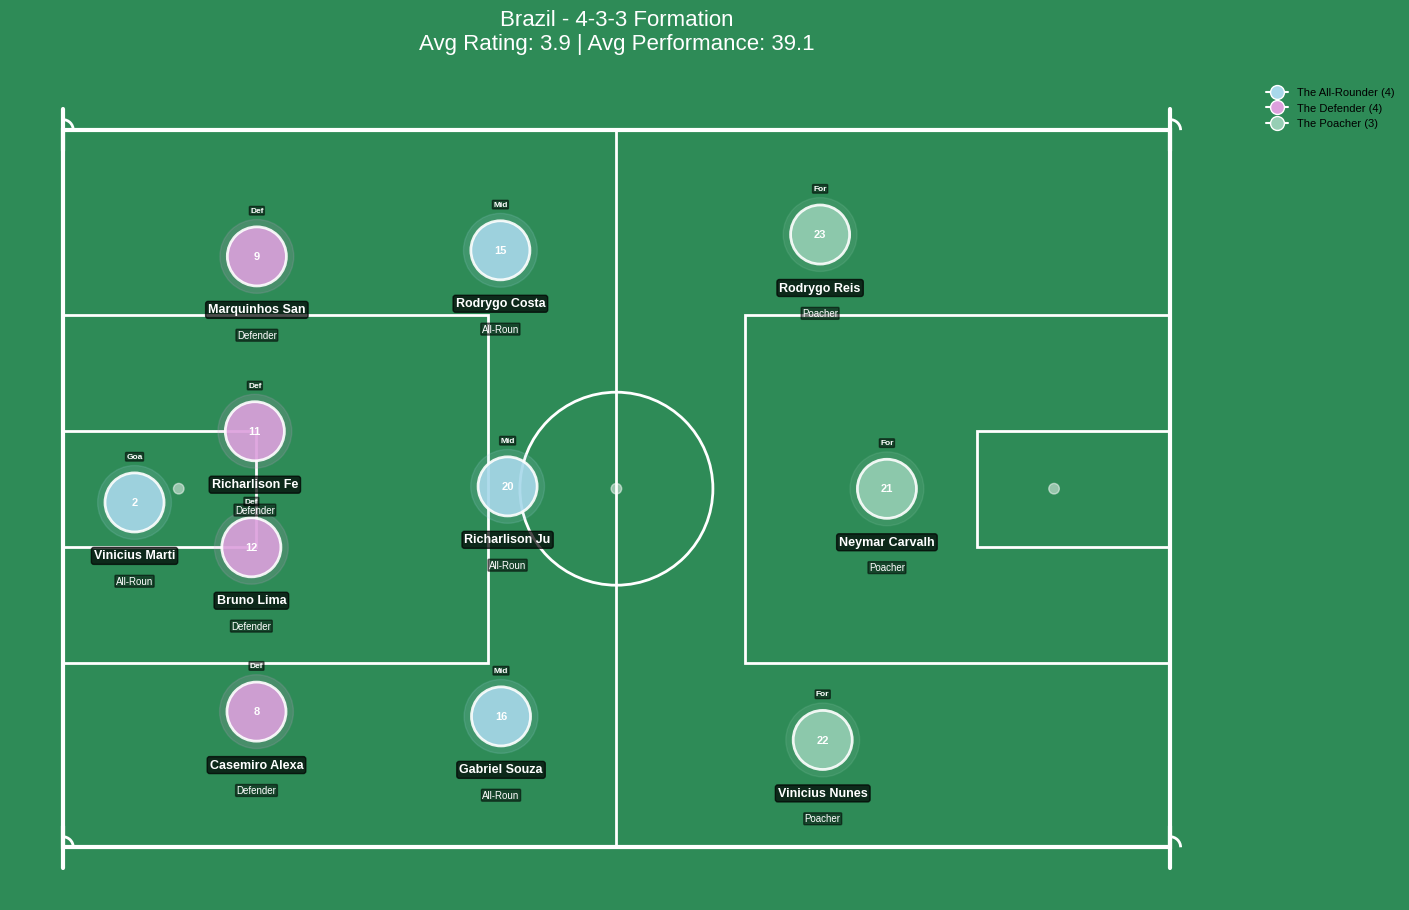

 Pitch visualization created for Brazil
  Creating pitch visualization for France...


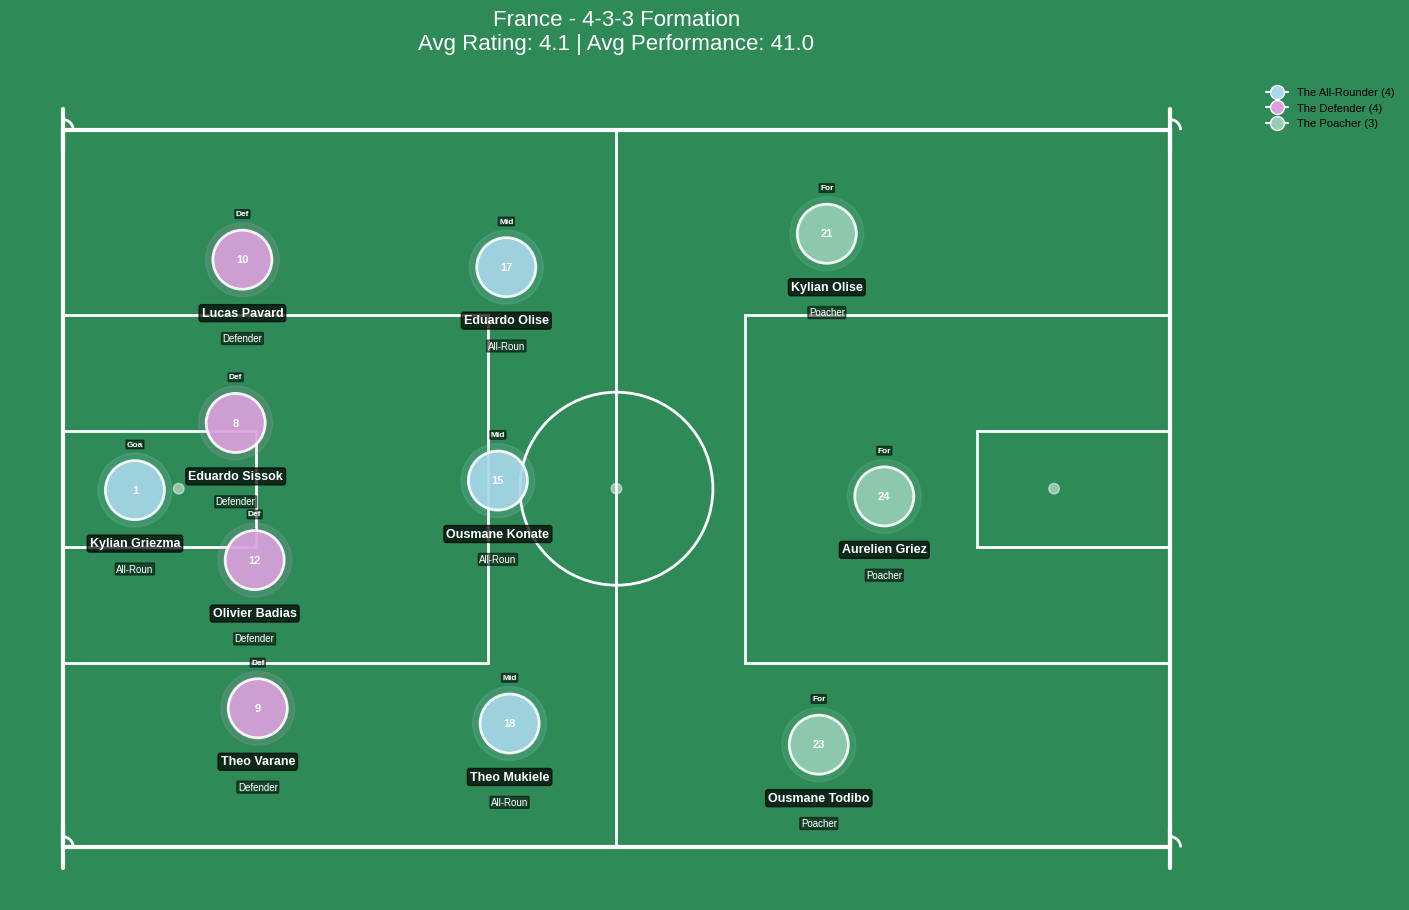

 Pitch visualization created for France
  Creating pitch visualization for Argentina...


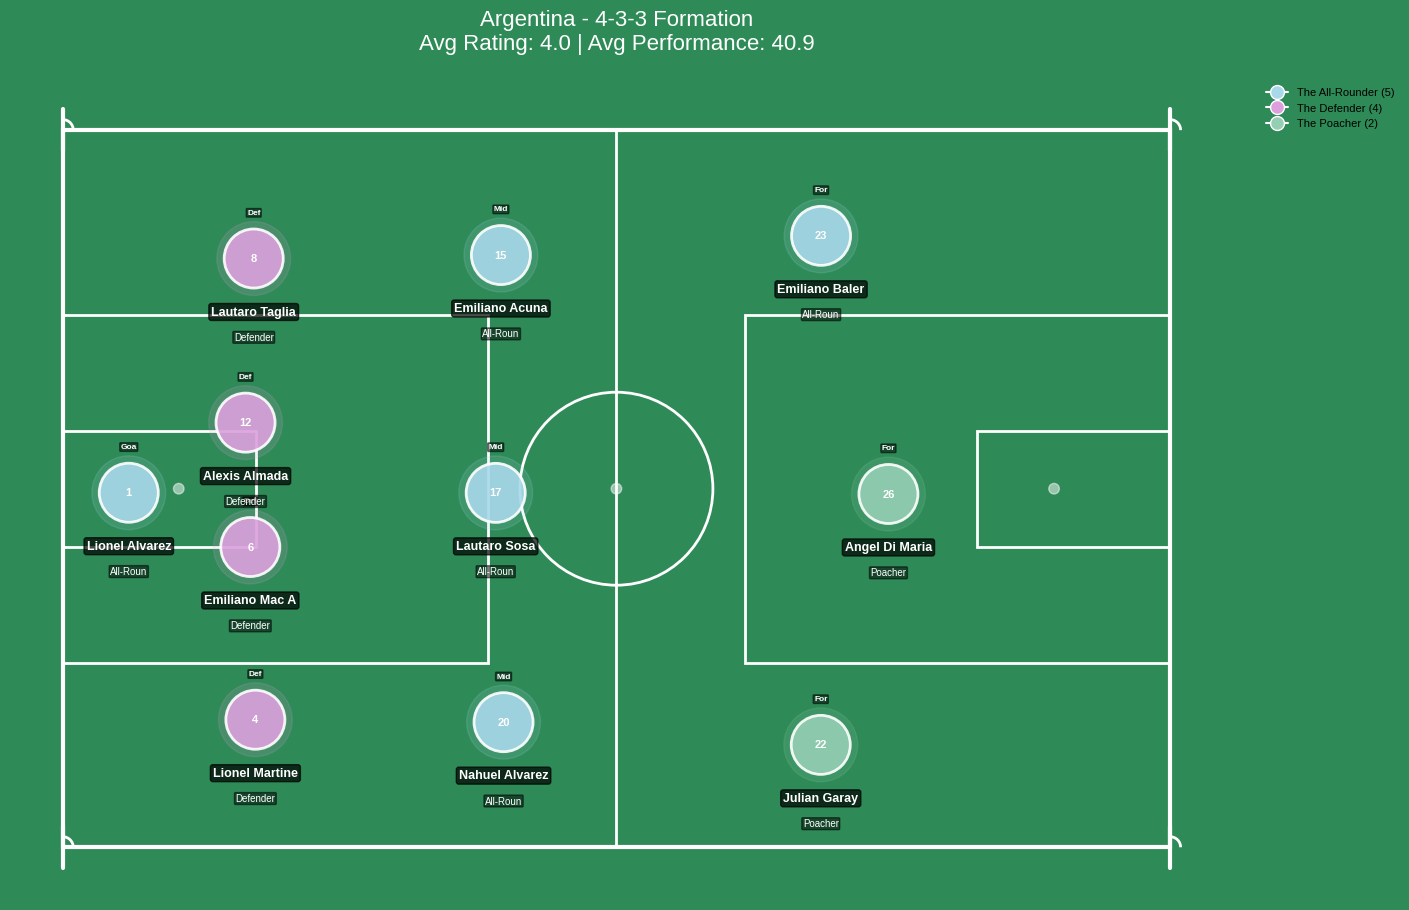

 Pitch visualization created for Argentina
  Creating pitch visualization for England...


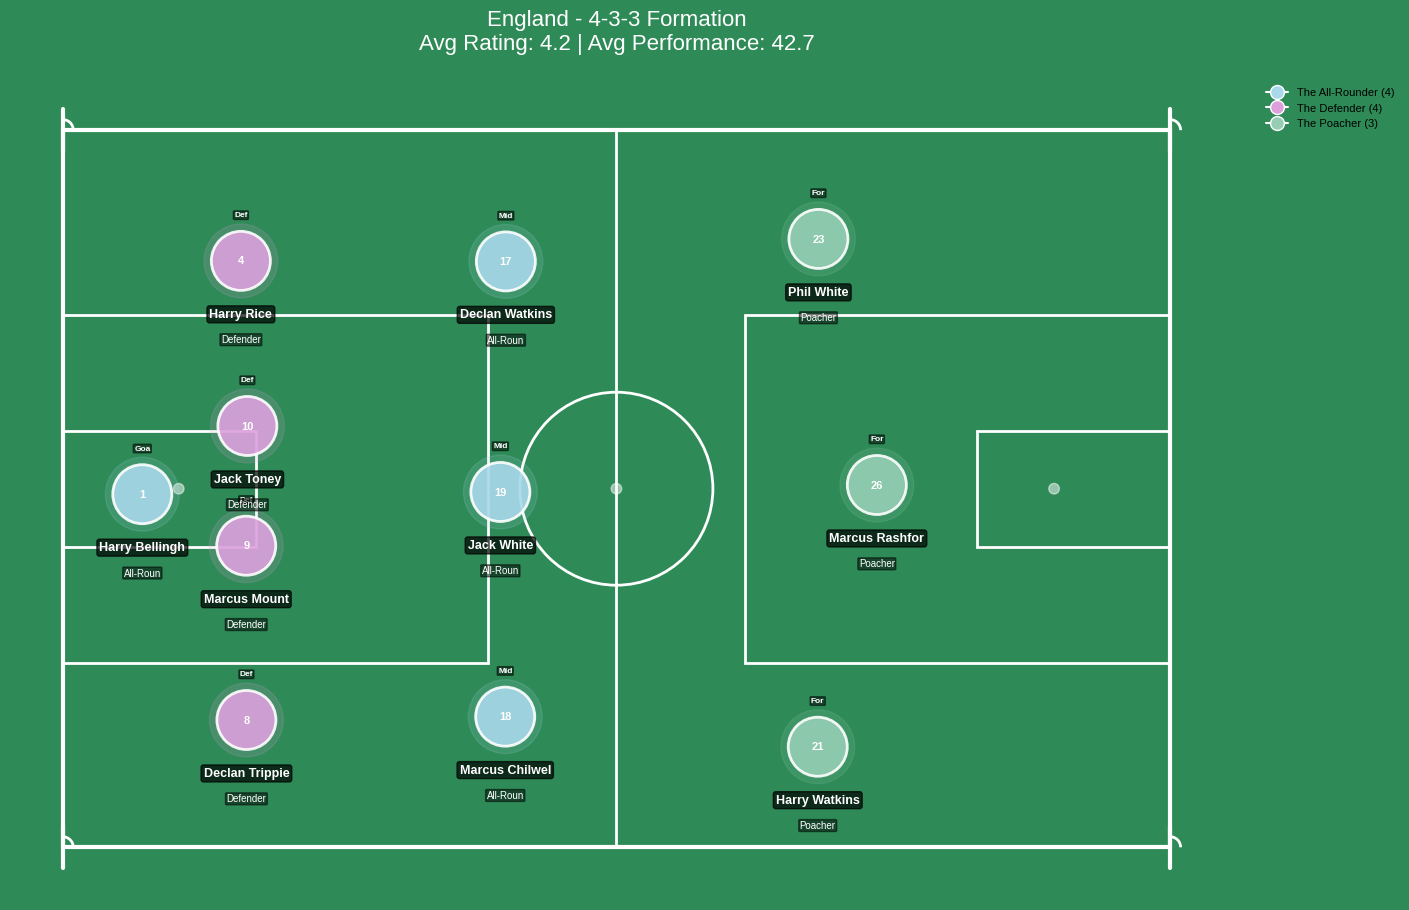

 Pitch visualization created for England
  Creating pitch visualization for Germany...


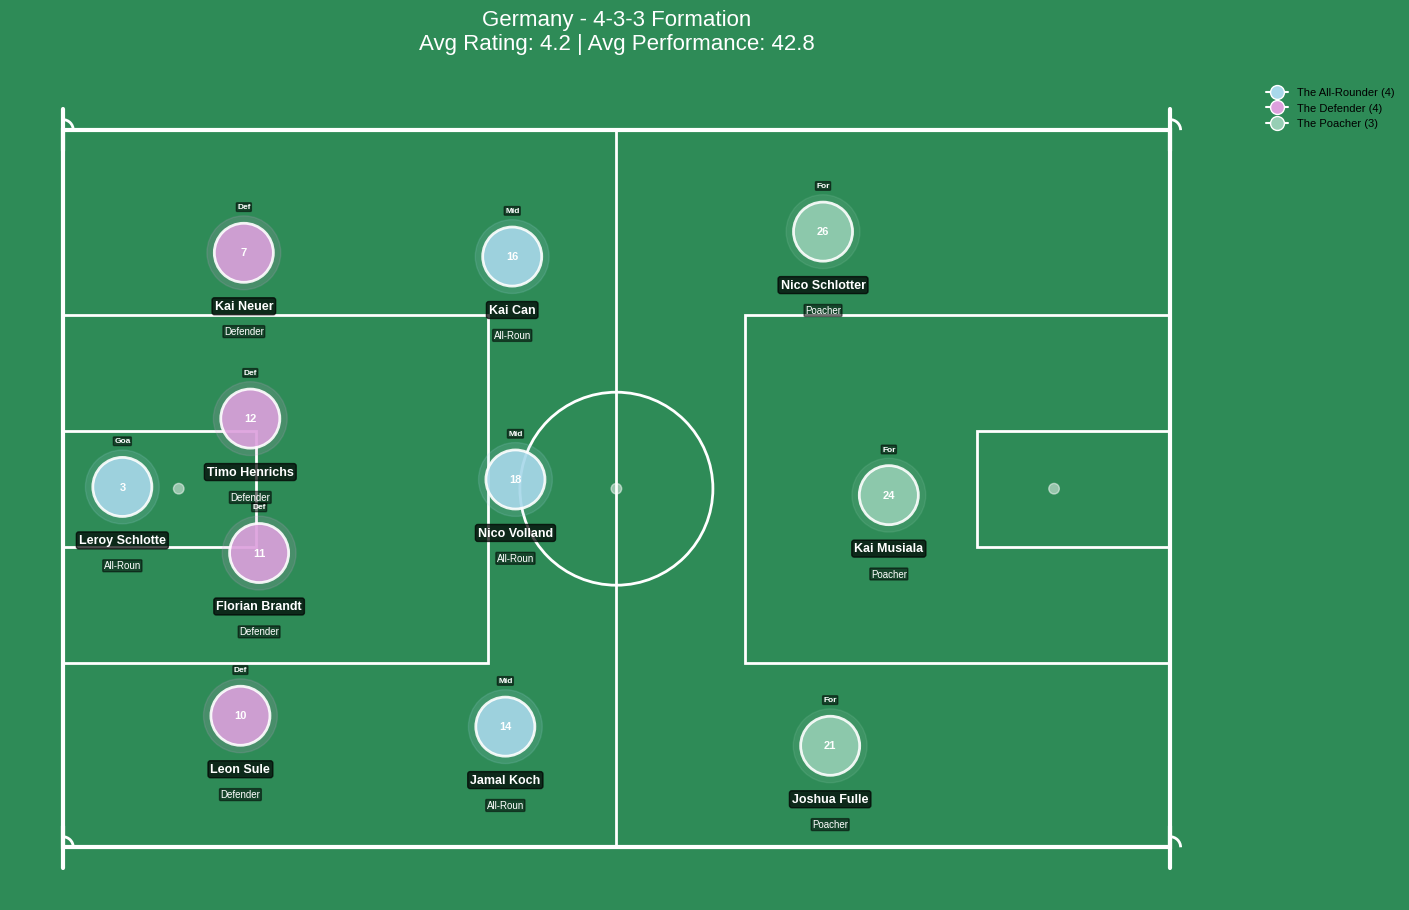

 Pitch visualization created for Germany
  Creating pitch visualization for Spain...


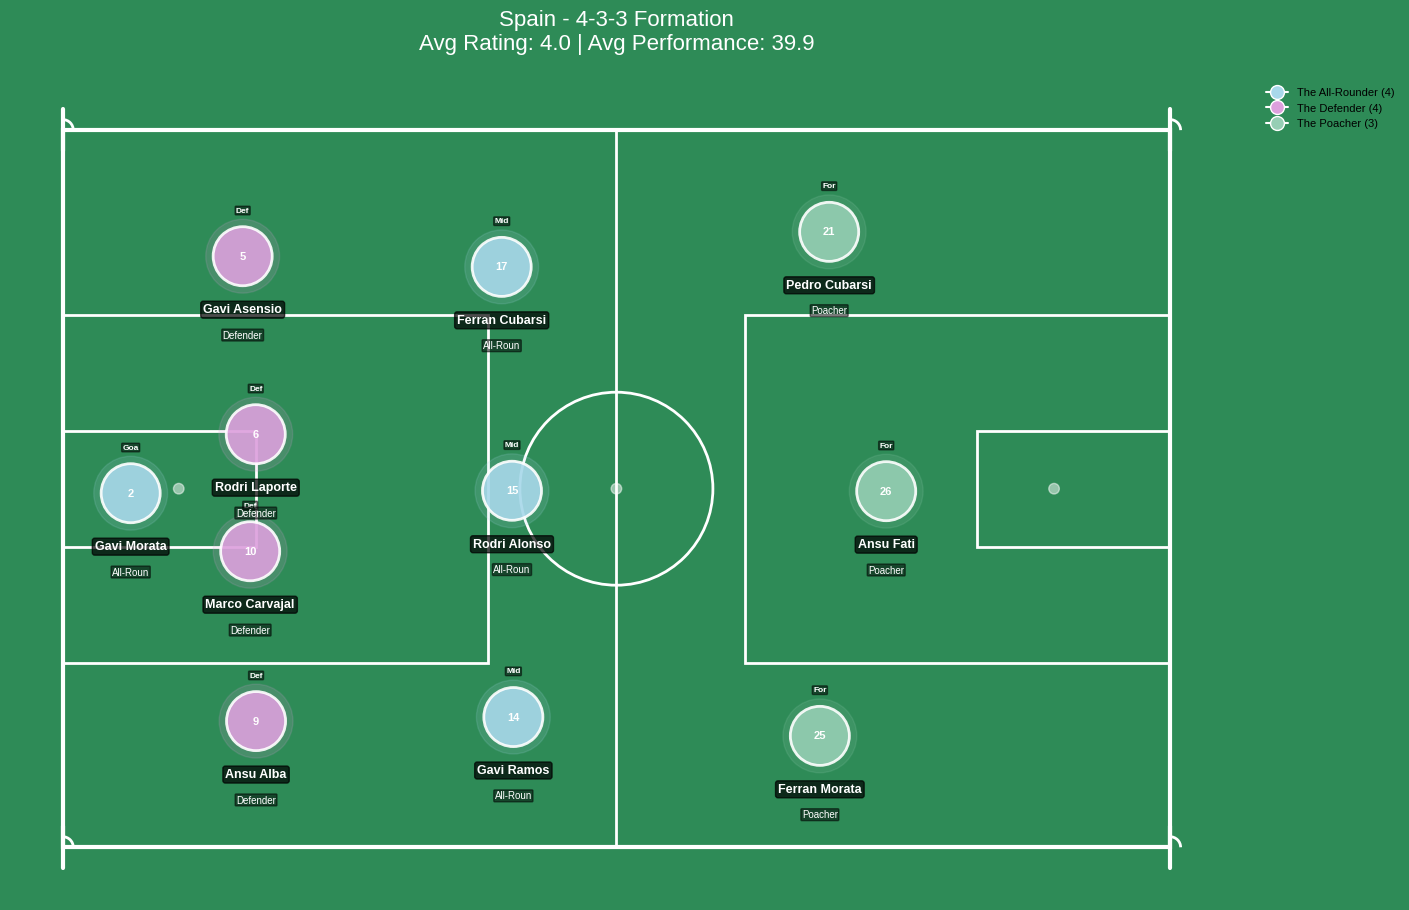

 Pitch visualization created for Spain

2. Creating Role Distribution Charts...
  Creating role distribution for Brazil...


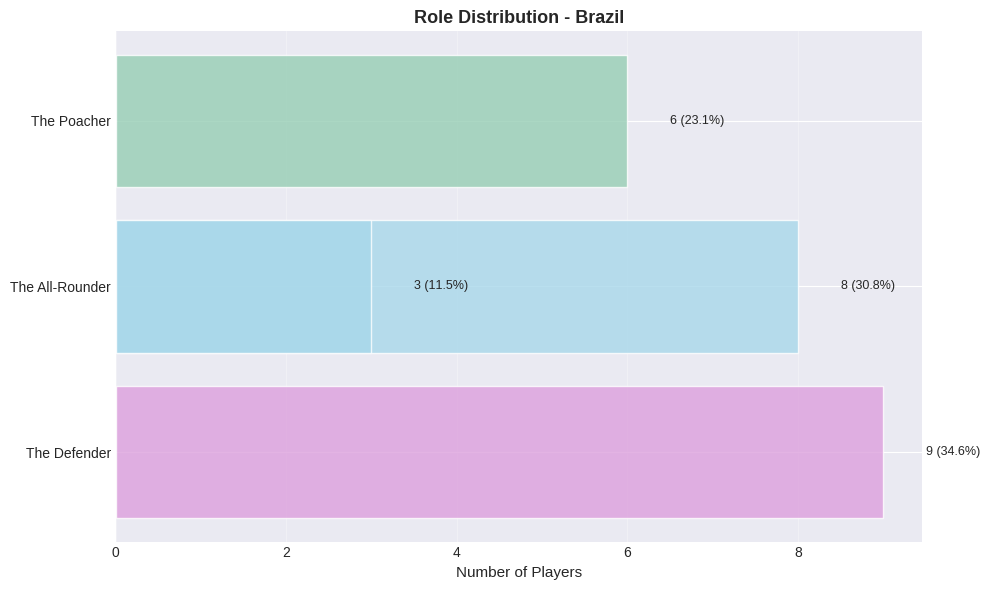

 Role distribution created for Brazil
  Creating role distribution for France...


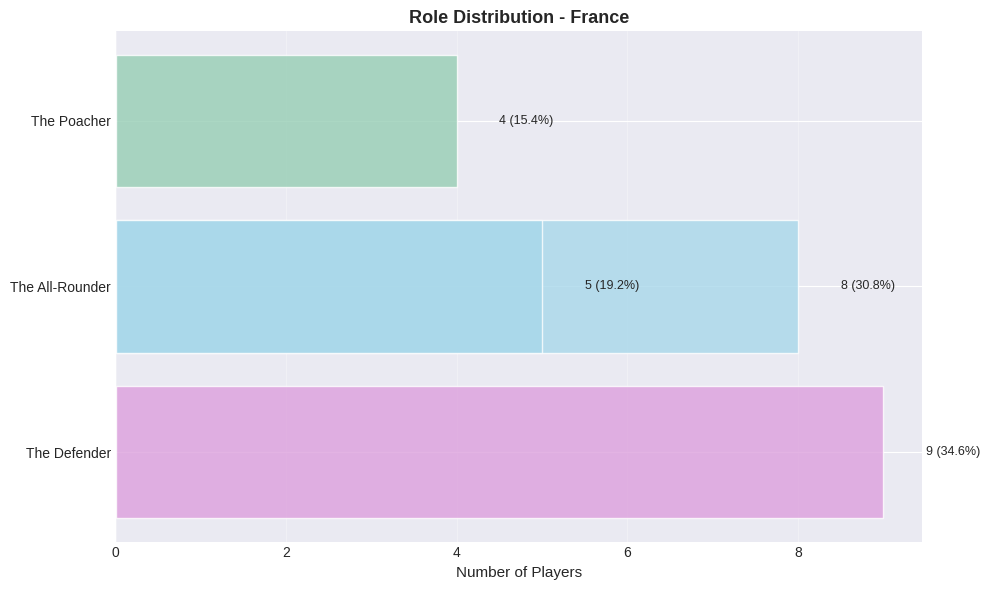

 Role distribution created for France
  Creating role distribution for Argentina...


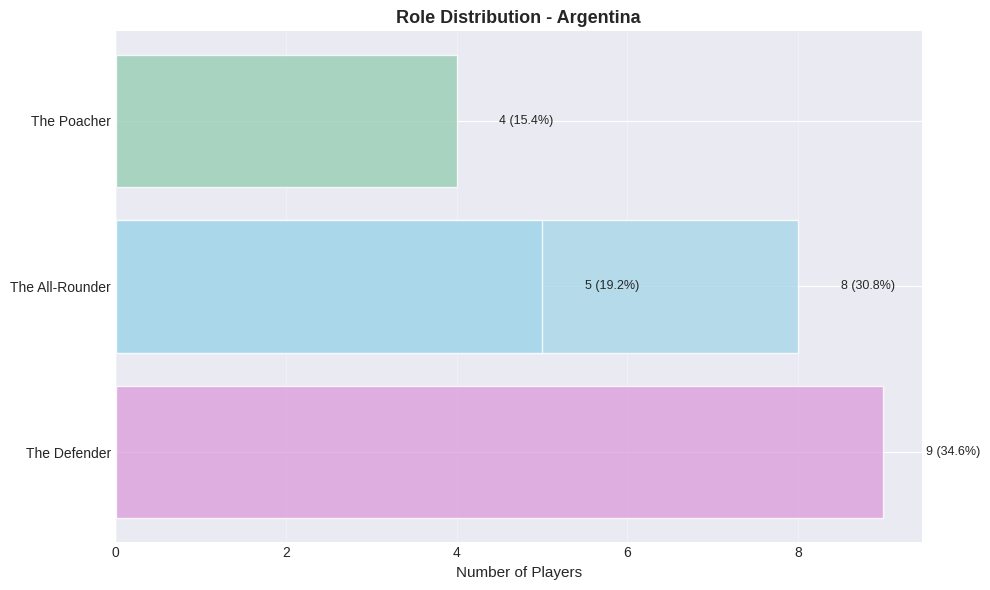

 Role distribution created for Argentina
  Creating role distribution for England...


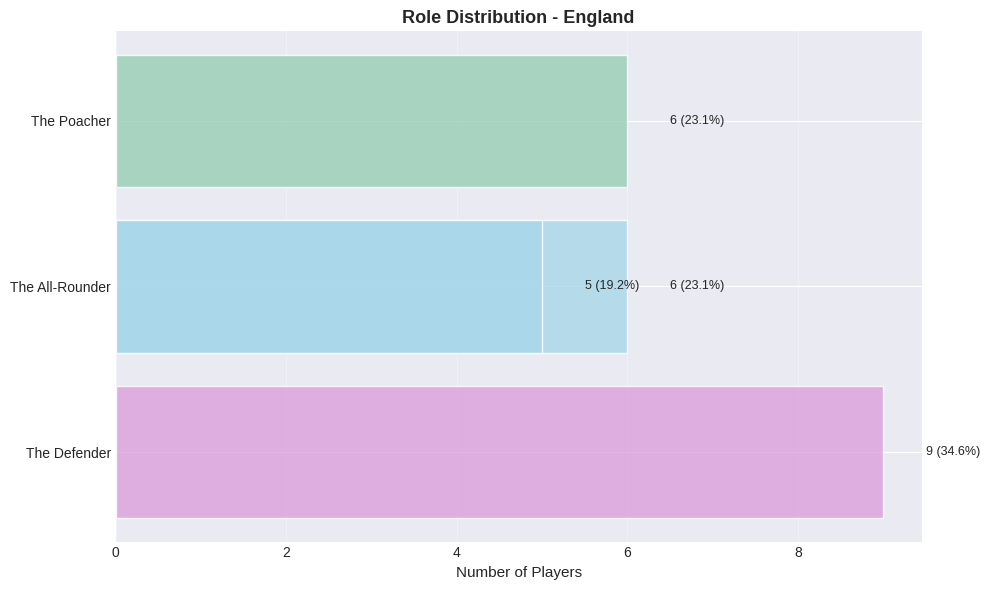

 Role distribution created for England
  Creating role distribution for Germany...


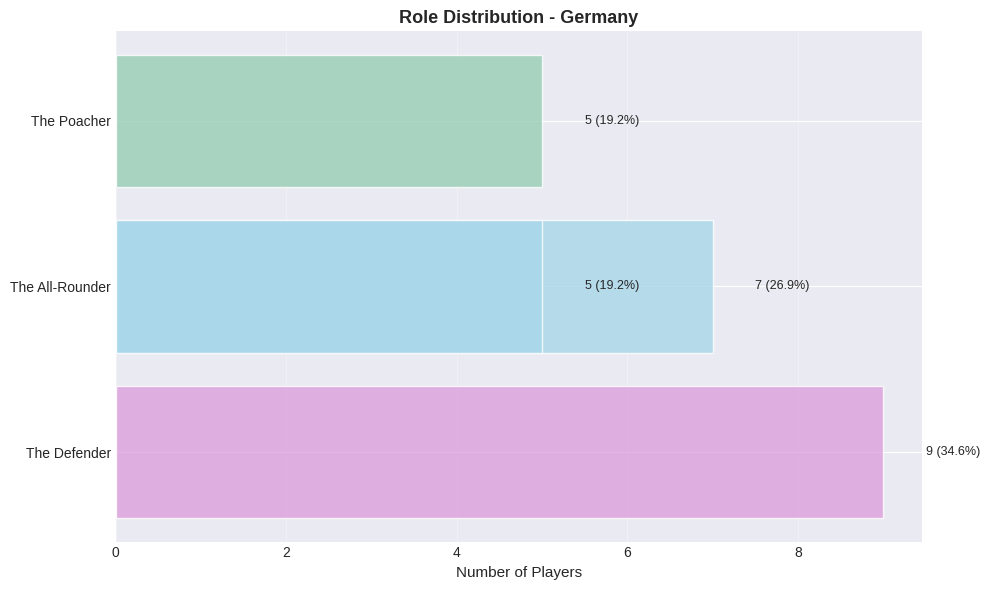

 Role distribution created for Germany
  Creating role distribution for Spain...


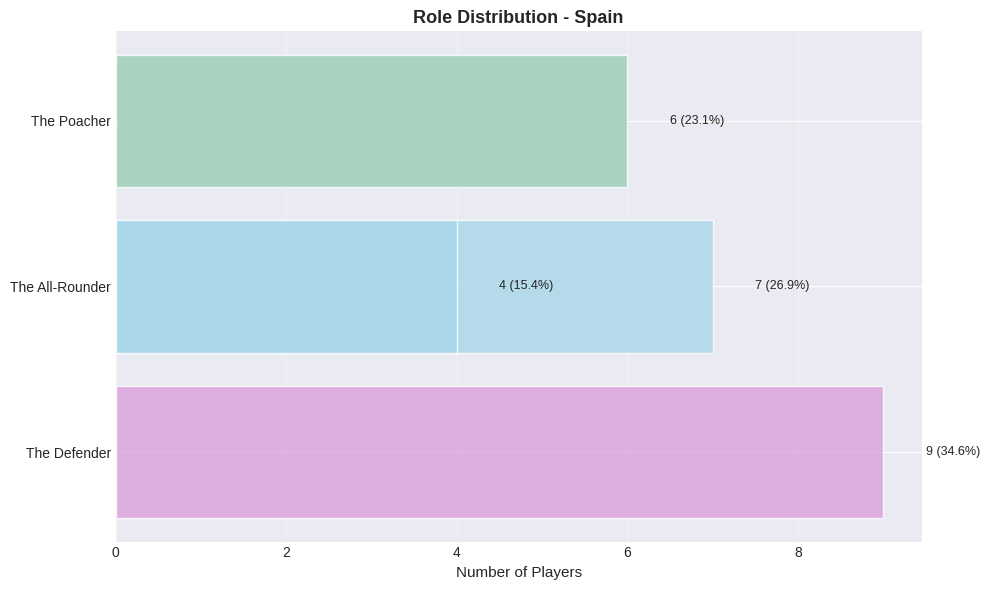

 Role distribution created for Spain

3. Creating Position Distribution Charts...
  Creating position distribution for Brazil...


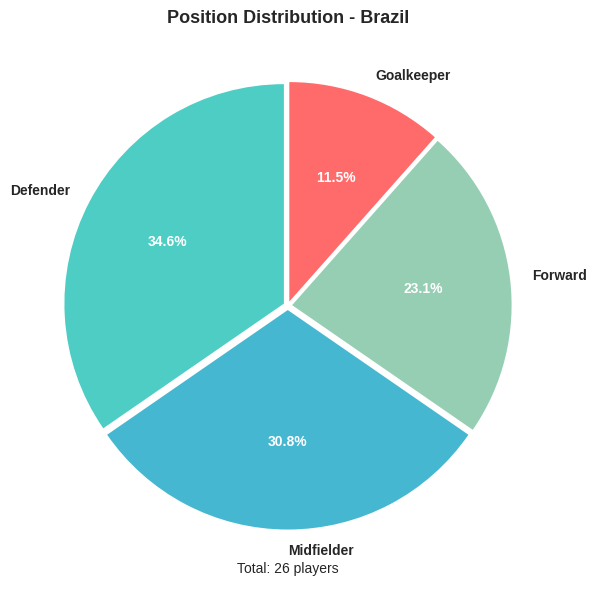

 Position distribution created for Brazil
  Creating position distribution for France...


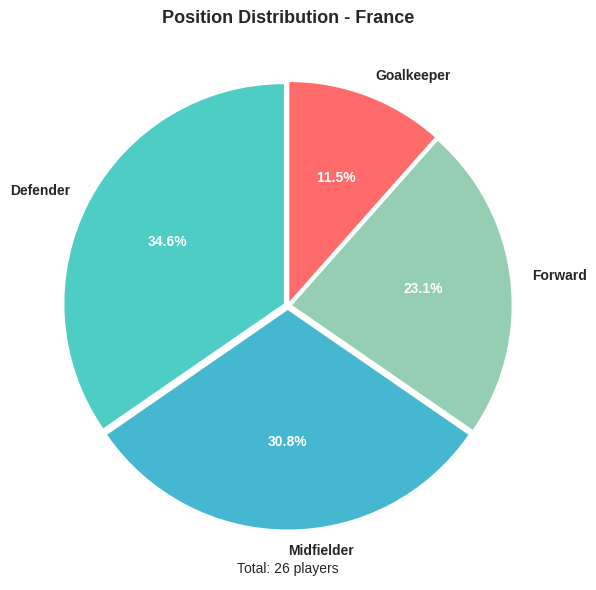

 Position distribution created for France
  Creating position distribution for Argentina...


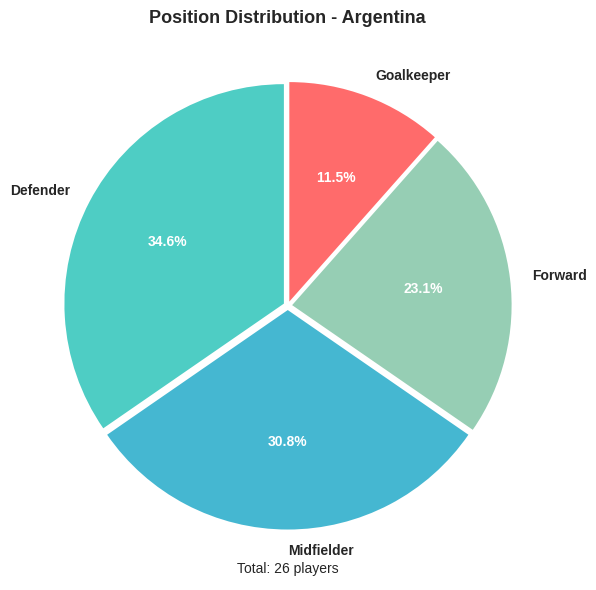

 Position distribution created for Argentina
  Creating position distribution for England...


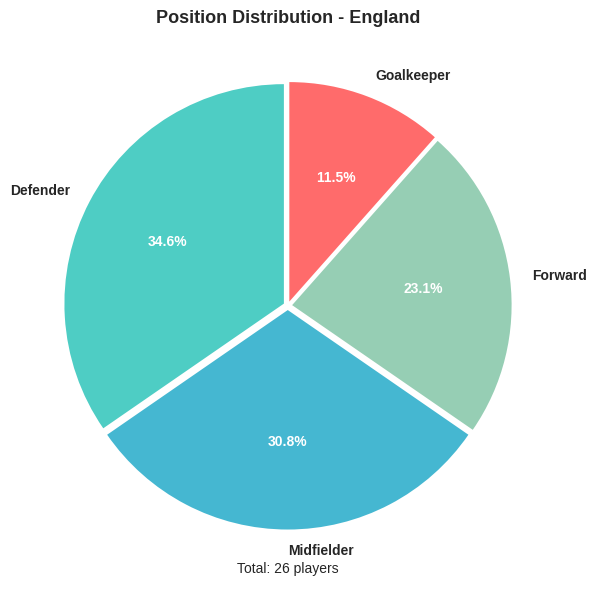

 Position distribution created for England
  Creating position distribution for Germany...


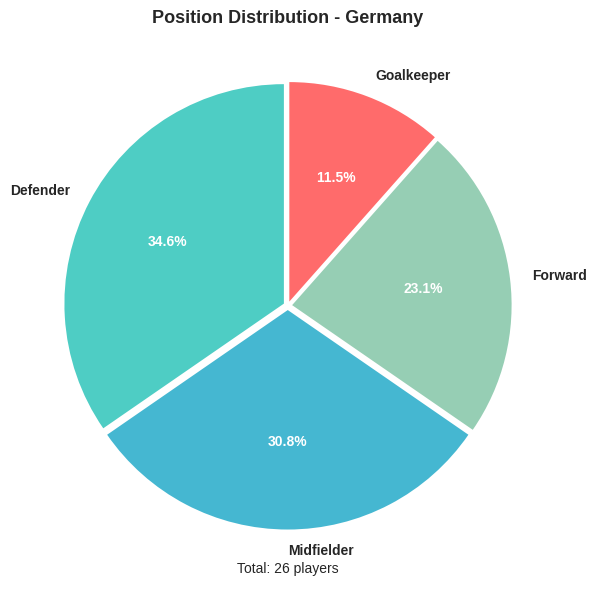

 Position distribution created for Germany
  Creating position distribution for Spain...


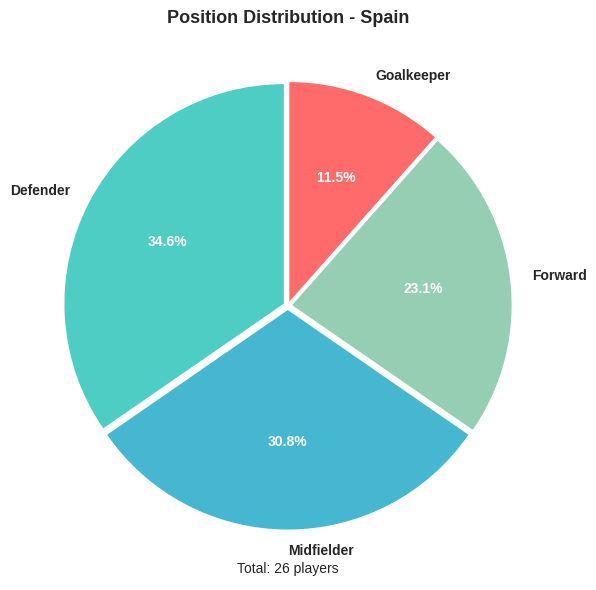

 Position distribution created for Spain

4. Creating Team Comparison Chart...


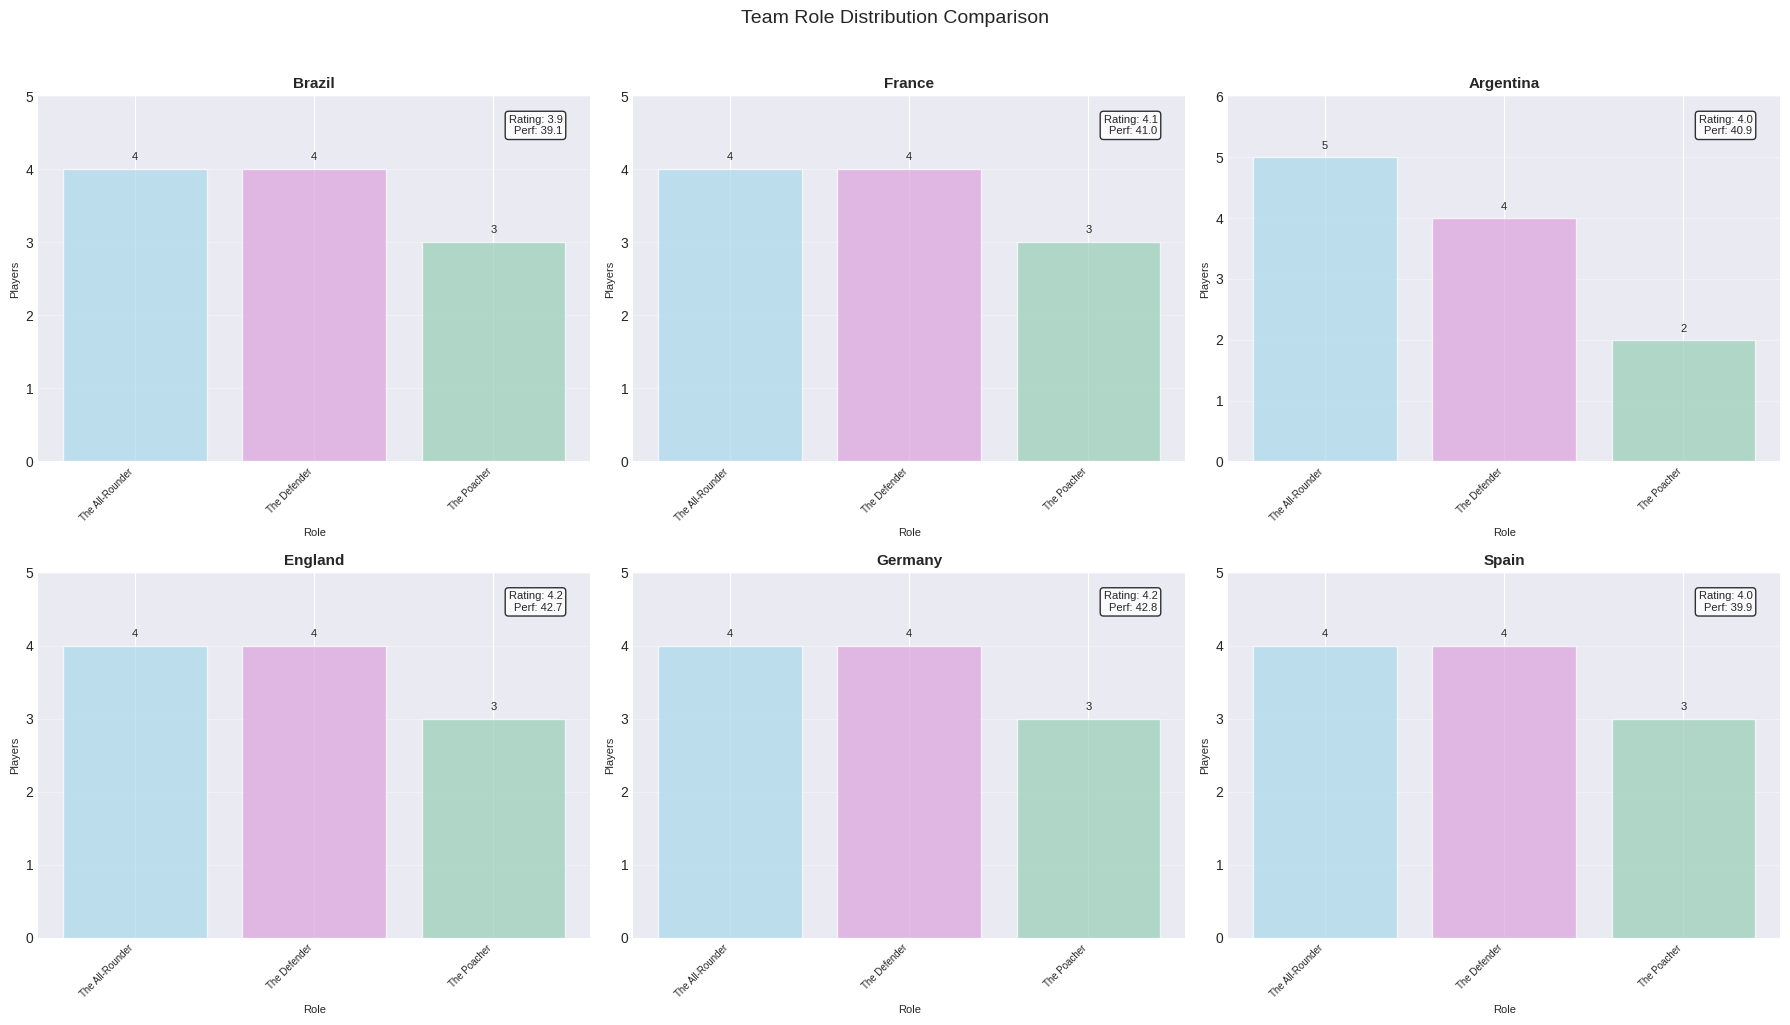

 Team comparison chart created

5. Creating Overall Role Distribution...


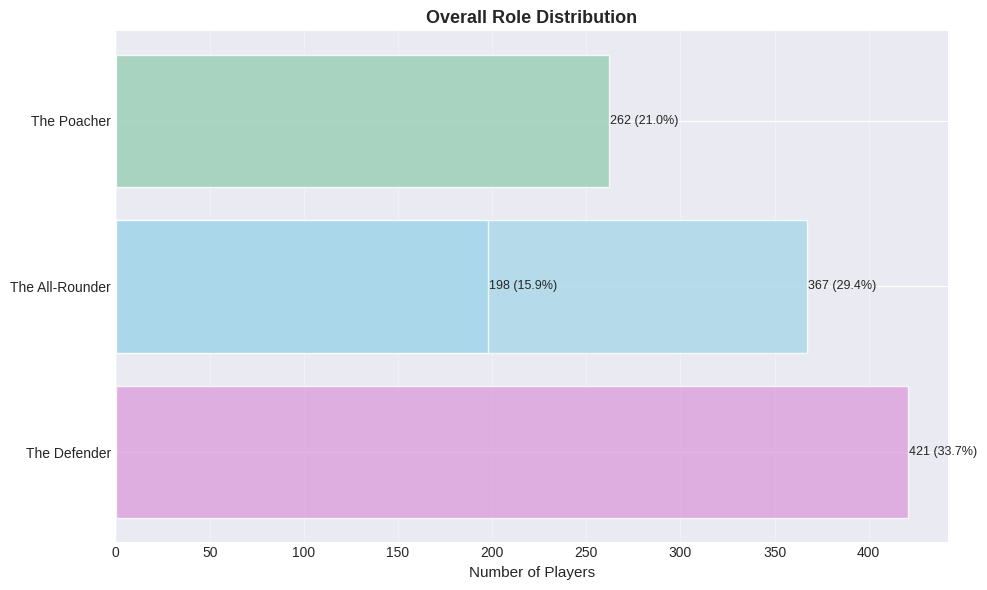

 Overall role distribution created

6. Creating Overall Position Distribution...


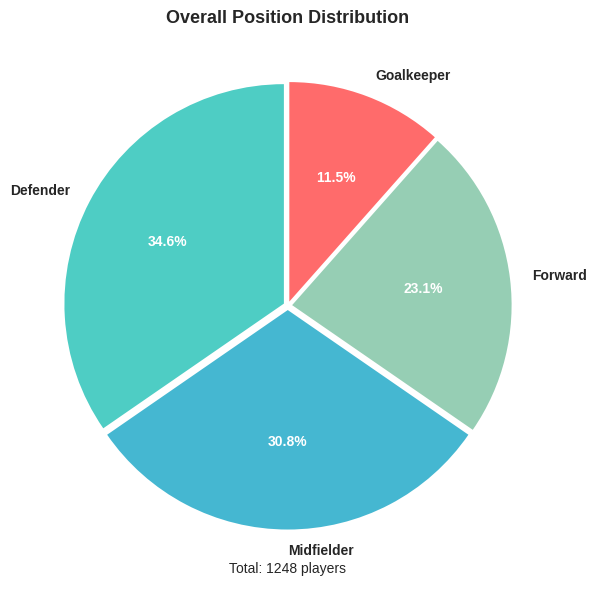

 Overall position distribution created


In [18]:
# ============================================
# VISUALIZE RESULTS
# ============================================

# 1. Create pitch visualizations for each team
print("\n1. Creating Pitch Visualizations...")
pitch_figures = {}

for team_name, team_data in optimized_teams.items():
    print(f"  Creating pitch visualization for {team_name}...")
    fig = create_team_pitch_viz(team_data, role_names, formation='4-3-3')
    if fig:
        pitch_figures[team_name] = fig
        plt.show()
        plt.close(fig)  # Close after showing to free memory
        print(f" Pitch visualization created for {team_name}")
    else:
        print(f" Failed to create pitch visualization for {team_name}")

# 2. Create individual role distribution charts
print("\n2. Creating Role Distribution Charts...")
role_figures = {}

for team_name in optimized_teams.keys():
    print(f"  Creating role distribution for {team_name}...")
    fig = plot_role_distribution(df_filtered, role_names, team_name=team_name)
    if fig:
        role_figures[team_name] = fig
        plt.show()
        plt.close(fig)
        print(f" Role distribution created for {team_name}")
    else:
        print(f" Failed to create role distribution for {team_name}")

# 3. Create position distribution charts
print("\n3. Creating Position Distribution Charts...")
position_figures = {}

for team_name in optimized_teams.keys():
    print(f"  Creating position distribution for {team_name}...")
    fig = plot_position_distribution(df_filtered, team_name=team_name)
    if fig:
        position_figures[team_name] = fig
        plt.show()
        plt.close(fig)
        print(f" Position distribution created for {team_name}")
    else:
        print(f" Failed to create position distribution for {team_name}")

# 4. Create team comparison chart
print("\n4. Creating Team Comparison Chart...")
comparison_fig = visualize_team_comparison(optimized_teams, role_names)
if comparison_fig:
    plt.show()
    plt.close(comparison_fig)
    print(" Team comparison chart created")
else:
    print(" Failed to create team comparison chart")

# 5. Create overall role distribution
print("\n5. Creating Overall Role Distribution...")
overall_fig = plot_role_distribution(df_filtered, role_names)
if overall_fig:
    plt.show()
    plt.close(overall_fig)
    print(" Overall role distribution created")
else:
    print(" Failed to create overall role distribution")

# 6. Create overall position distribution
print("\n6. Creating Overall Position Distribution...")
overall_pos_fig = plot_position_distribution(df_filtered)
if overall_pos_fig:
    plt.show()
    plt.close(overall_pos_fig)
    print(" Overall position distribution created")
else:
    print(" Failed to create overall position distribution")

In [19]:
# ============================================
# EXPORT RESULTS
# ============================================

# Export player data with roles
df_filtered.to_csv('player_data_with_roles_final.csv', index=False)
print("Player data with roles exported: 'player_data_with_roles_final.csv'")

# Export optimized teams
optimized_export = []
for team_name, team_data in optimized_teams.items():
    for player in team_data['players'][:11]:
        optimized_export.append({
            'team': team_name,
            'formation': team_data['formation'],
            'player_name': player['player_name'],
            'position': player['position'],
            'role': role_names.get(player['cluster'], 'Unknown'),
            'rating': player['player_rating'],
            'performance': player['performance_score'],
            'goals': player.get('goals', 0),
            'assists': player.get('assists', 0)
        })

optimized_df = pd.DataFrame(optimized_export)
optimized_df.to_csv('optimized_starting_xis.csv', index=False)
print("Optimized starting XIs exported: 'optimized_starting_xis.csv'")

# Export team summaries
team_summaries = []
for team_name, team_data in optimized_teams.items():
    team_summaries.append({
        'team': team_name,
        'formation': team_data['formation'],
        'avg_rating': team_data['avg_rating'],
        'avg_performance': team_data['avg_performance'],
        'n_players': team_data['n_players'],
        'score': team_data['score']
    })

summary_df = pd.DataFrame(team_summaries)
summary_df.to_csv('team_summaries_optimized.csv', index=False)

Player data with roles exported: 'player_data_with_roles_final.csv'
Optimized starting XIs exported: 'optimized_starting_xis.csv'
